# Practicing Simple Linear Regression: Predicting MPG
Author: Brad Sheese
---
NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.
---
This exercise is designed to supplement the assigned chapter on regression. It reviews some of the key concepts and allows you to implement simple linear regression using SciKit Learn.


## Data Source and InformationFor this exercise, we will be using a dataset that looks at factors associated with car mileage per gallon. This dataset has been around a long while, and is commonly used when teaching regression. The version of the data and the following description is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.names).```1. Title: Auto-Mpg Data2. Number of Instances: 3983. Number of Attributes: 9 including the class attribute4. Attribute Information:    1. mpg:           continuous    2. cylinders:     multi-valued discrete    3. displacement:  continuous    4. horsepower:    continuous    5. weight:        continuous    6. acceleration:  continuous    7. model year:    multi-valued discrete    8. origin:        multi-valued discrete    9. car name:      string (unique for each instance)5. Missing Attribute Values: horsepower has 6 missing values```


## Problem 1: Our goal is to predict MPG using the other variables in the dataset. What issues can you identify based on the information provided above that need to be addressed before we conduct our analysis?


In [2]:
problem1 = ""
print(problem1)



---
## Retrieving Data, Constructing Dataframe


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load raw data
raw = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data', sep='\t', header=None)
columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'modelyear', 'origin', 'carname']

# Process into dataframe
raw0 = raw[0].str.split(expand=True)
df = pd.concat([raw0, raw[1]], axis=1)
df.columns = columns
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,modelyear,origin,carname
0,18.0,8,307.0,130.0,3504.,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.,10.5,70,1,ford torino


## Problem 2: Preliminaries* Inspect, clean, and standardize the data.* Correct any problems you can.* Note any unresolved problems.* WARNING! Due to the way Python handles regex you will need to turn off regex if you want to write code that works with a question mark. For example, `df['horsepower'].str.contains('?', regex=False)` will throw an error if you omit the regex argument.


In [4]:
# enter and test your code here


<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   mpg           398 non-null    str  
 1   cylinders     398 non-null    str  
 2   displacement  398 non-null    str  
 3   horsepower    398 non-null    str  
 4   weight        398 non-null    str  
 5   acceleration  398 non-null    str  
 6   modelyear     398 non-null    str  
 7   origin        398 non-null    str  
 8   carname       398 non-null    str  
dtypes: str(9)
memory usage: 28.1 KB

Missing values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
modelyear       0
origin          0
carname         0
dtype: int64

Horsepower values containing '?':
6

Missing values after conversion:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
modelyear       0
origin          0
carname     

## Problem 3: AnalysisUse simple linear regression and visualizations to determine which variables are associated with higher MPG. Look at all of the possible numeric predictors. Use loops, don't repeat the same code over and over. Make your visualizations nice (labels, titles, etc.).


Simple Linear Regression: Each Predictor vs. MPG
cylinders:
   slope = -3.558, intercept = 42.92, R2 = 0.6047



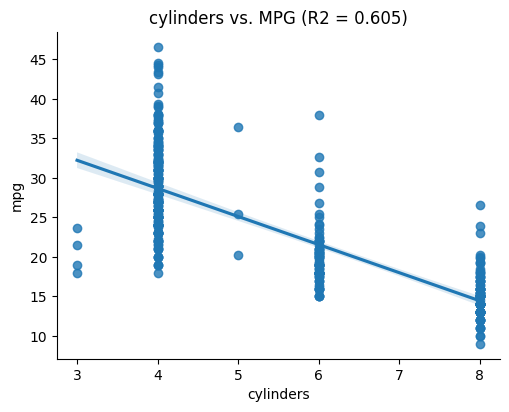


displacement:
   slope = -0.060, intercept = 35.12, R2 = 0.6482



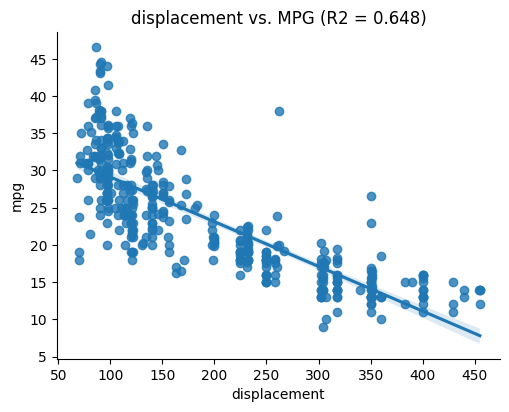


horsepower:
   slope = -0.158, intercept = 39.94, R2 = 0.6059



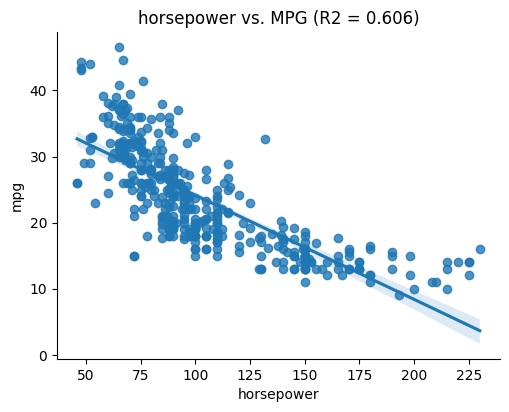


weight:
   slope = -0.008, intercept = 46.22, R2 = 0.6926



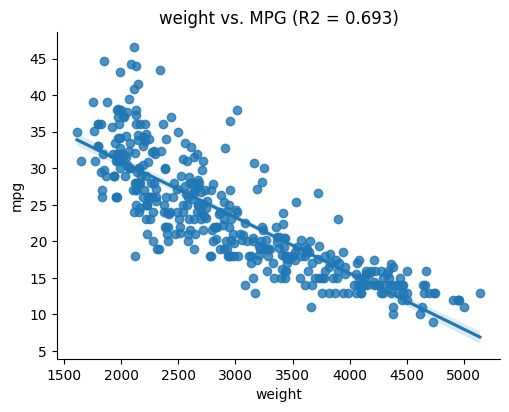


acceleration:
   slope = 1.198, intercept = 4.83, R2 = 0.1792



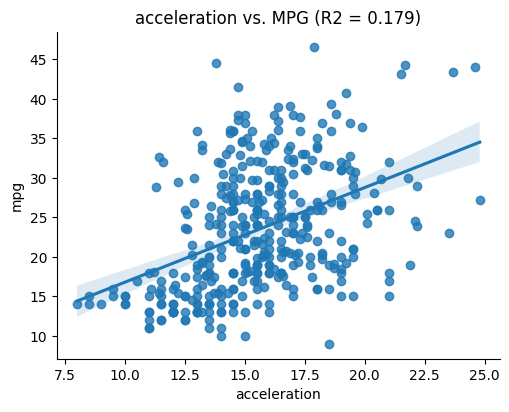


modelyear:
   slope = 1.230, intercept = -70.01, R2 = 0.3370



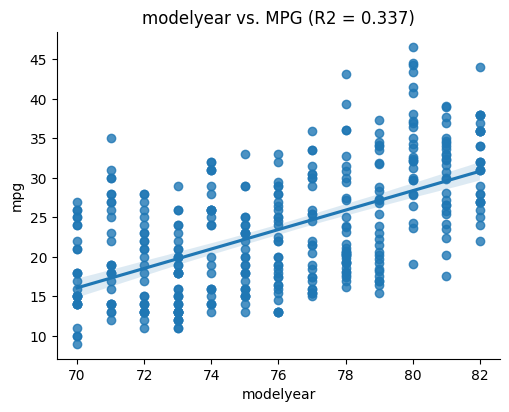


origin:
   slope = 5.477, intercept = 14.81, R2 = 0.3195



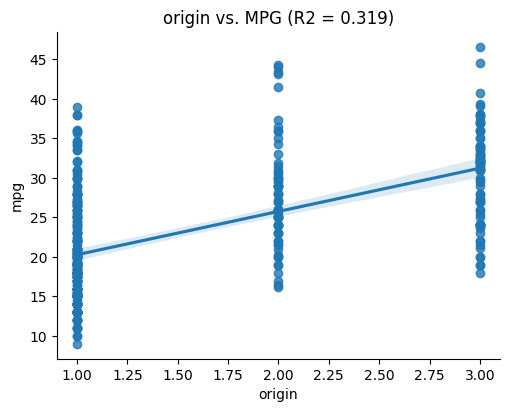

In [5]:
# enter and test your code here


### Residual Diagnostics for Each ModelNow let's check the residual plots for each predictor. We're looking for random scatter around 0 -- any pattern suggests the linear model may not be appropriate.


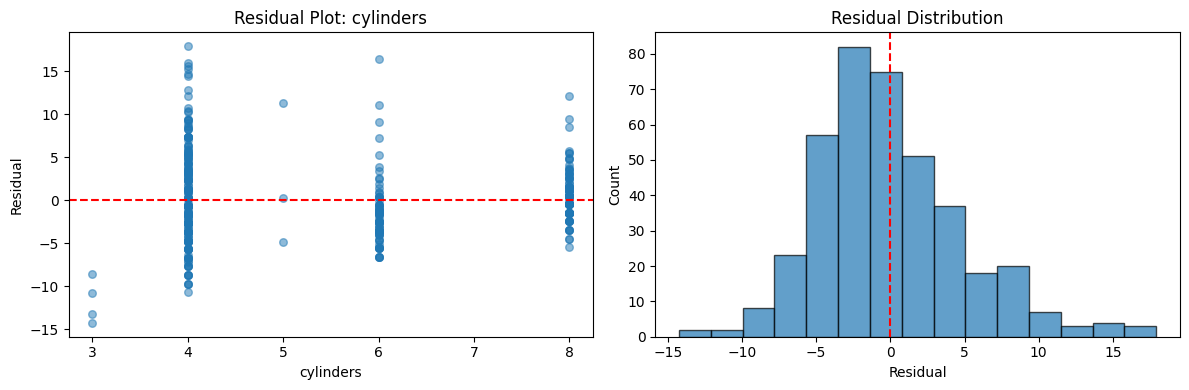

cylinders: R2 = 0.6047, Residual std = 4.90



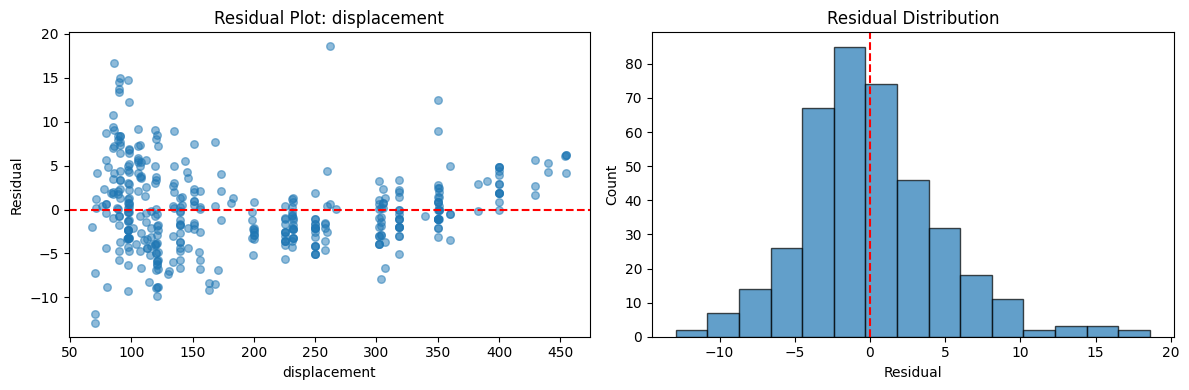

displacement: R2 = 0.6482, Residual std = 4.62



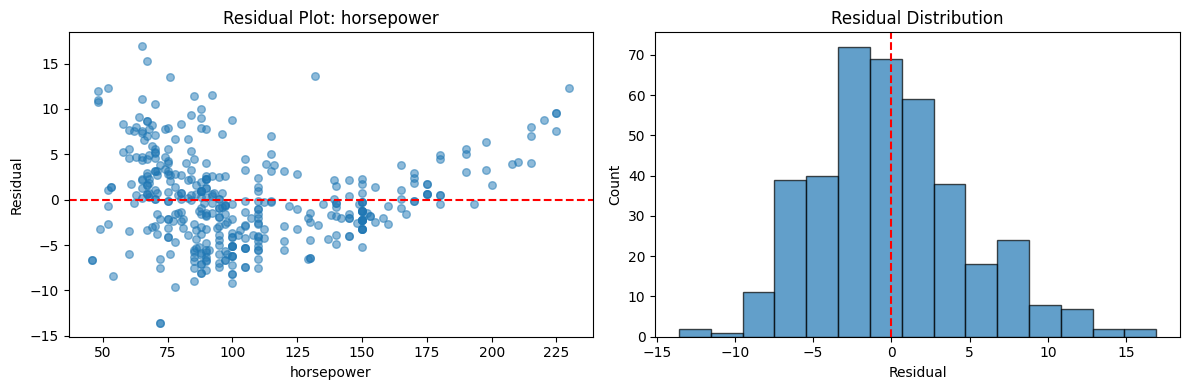

horsepower: R2 = 0.6059, Residual std = 4.89



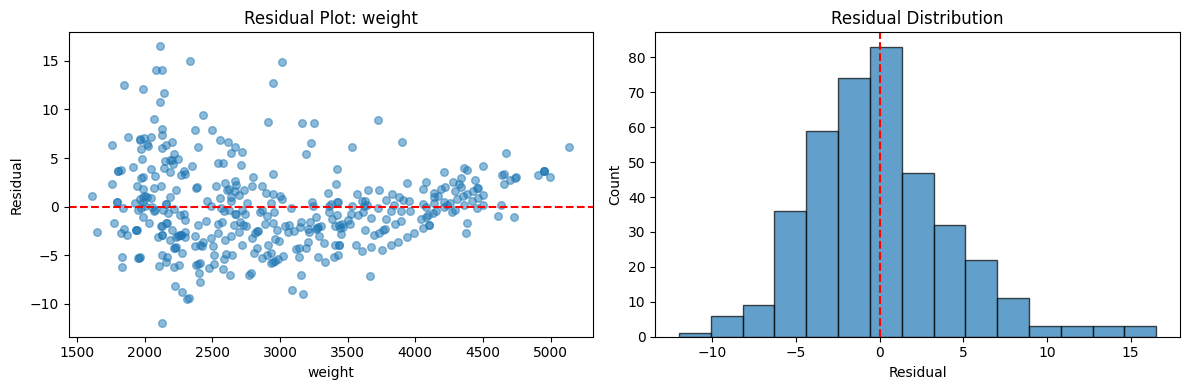

weight: R2 = 0.6926, Residual std = 4.32



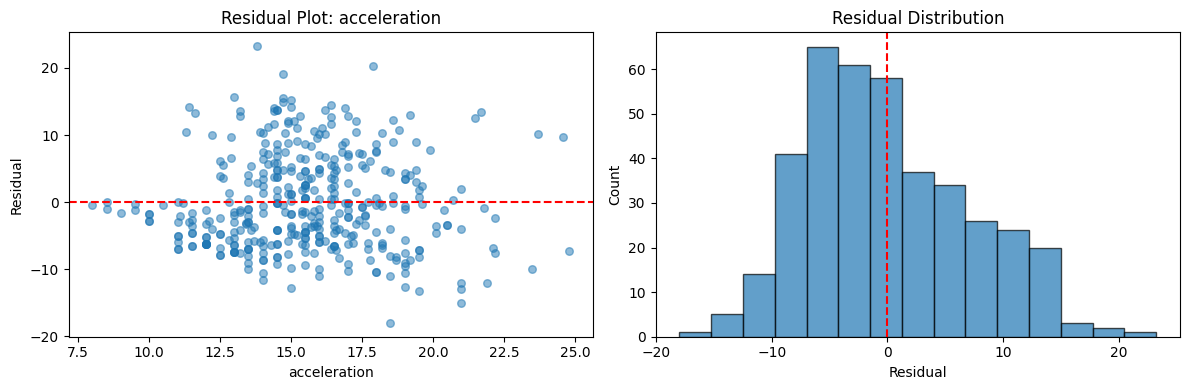

acceleration: R2 = 0.1792, Residual std = 7.06



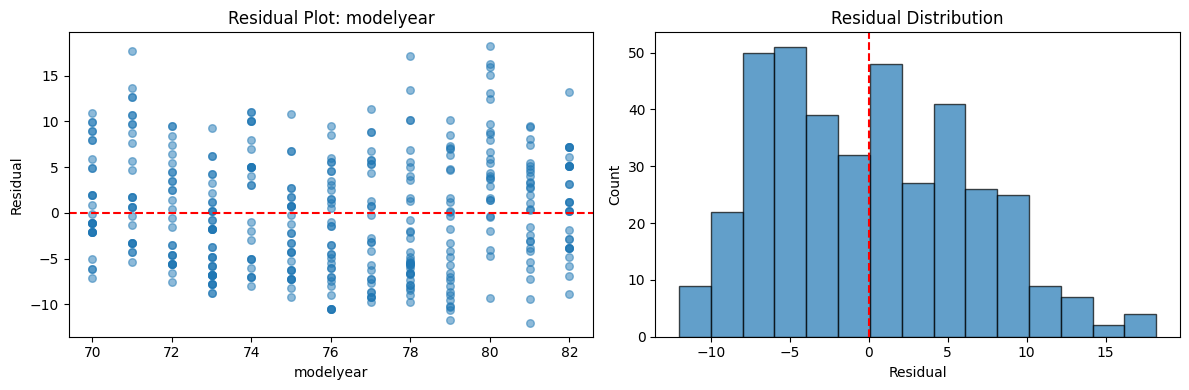

modelyear: R2 = 0.3370, Residual std = 6.35



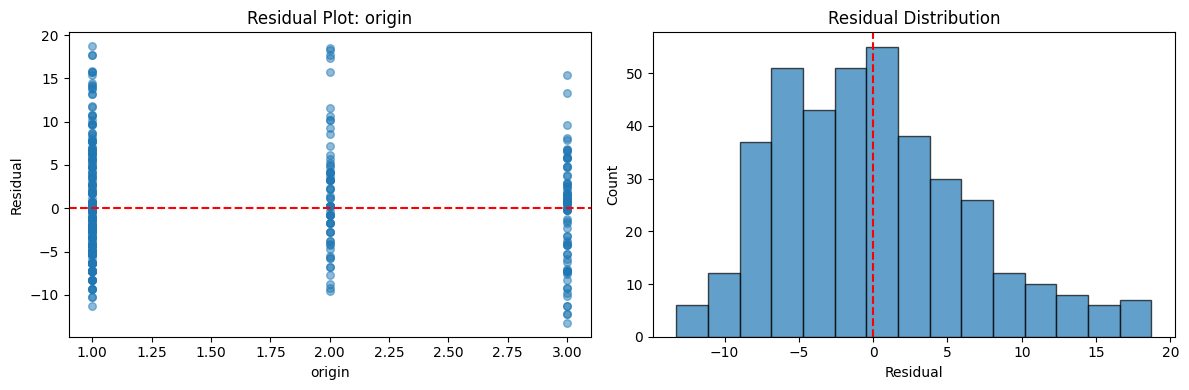

origin: R2 = 0.3195, Residual std = 6.43



In [6]:
# enter and test your code here


### R-Squared Comparison Across PredictorsLet's compare how well each predictor explains the variation in MPG.


Predictors ranked by R-squared:
  weight: 0.6926 (69.3% of variation explained)
  displacement: 0.6482 (64.8% of variation explained)
  horsepower: 0.6059 (60.6% of variation explained)
  cylinders: 0.6047 (60.5% of variation explained)
  modelyear: 0.3370 (33.7% of variation explained)
  origin: 0.3195 (31.9% of variation explained)
  acceleration: 0.1792 (17.9% of variation explained)



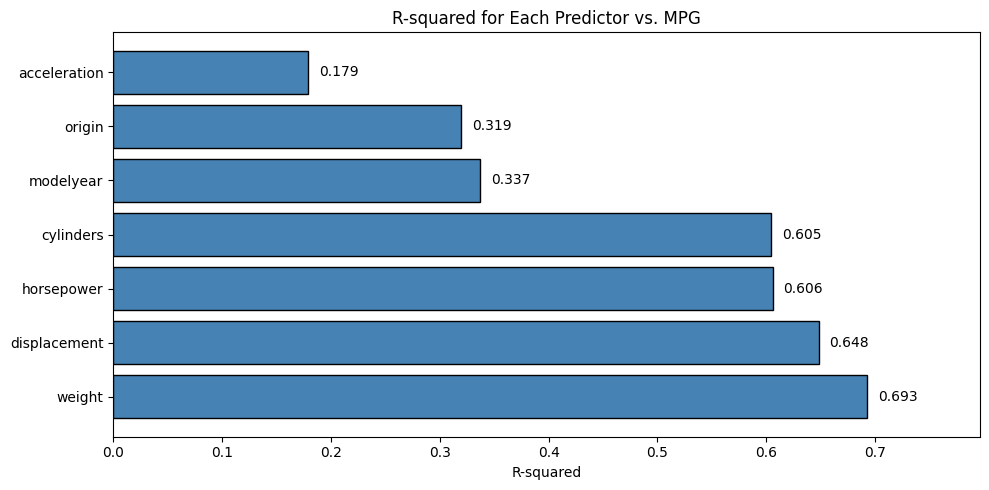

Best single predictor: weight (R2 = 0.6926)
Interpretation: 69.3% of the variation in MPG is explained by weight.


In [7]:
# enter and test your code here


### Checking for Outliers and Leverage PointsLet's examine the best model more closely. Are there any observations with unusually large residuals or extreme predictor values?


In [8]:
# enter and test your code here


Observation with largest residual:
  weight = 2110.0
  Actual MPG = 46.6
  Predicted MPG = 30.1
  Residual = 16.5

weight range: 1613.0 to 5140.0
Mean weight: 2977.6

With point:    slope = -0.0076, R2 = 0.6926
Without point: slope = -0.0076, R2 = 0.6973
Slope difference: 0.0001
This point is NOT influential (slope barely changes).


## Problem 4: ConclusionWrite a concise but clear conclusion based on your analyses. Address these questions:1. Which single predictor is the best predictor of MPG? How good is it?2. Are the residual plots for the best model clean (random scatter), or do they show patterns?3. Are there any influential observations worth investigating?4. What would you recommend to someone trying to predict a car's fuel efficiency?

**Congratulations!** You have completed the Simple Linear Regression module. You now have a solid understanding of how to build, visualize, and diagnose linear models using both manual and professional tools.


In [9]:
conclusions = ""
print(conclusions)


### A Note on ExtrapolationIf you were to use your model to predict MPG for a car with, say, 500 horsepower or a weight of 10,000 lbs, that would be **extrapolation** -- those values are far outside the observed range of the data. The linear relationship observed within the data range may not hold at extreme values. A car with 500 horsepower is a fundamentally different kind of vehicle than the cars in this dataset (which range from about 46 to 230 horsepower).


In [10]:
# enter and test your code here


Observed weight range: 1613.0 to 5140.0

Prediction at median weight (2803.5): 24.8 MPG
Prediction at extreme weight (15420.0): -71.7 MPG

The extreme prediction is an extrapolation and should not be trusted.


## OPTIONAL Problem 5: If we average across car models by manufacturer, which manufacturer had the highest average MPG? Which had the greatest variability in MPG?


In [11]:
# enter and test your code here


Average MPG by Manufacturer (top 15):
              mean   std  count
manufacturer                   
vw            39.0   6.8      6
nissan        36.0   NaN      1
triumph       35.0   NaN      1
honda         33.8   4.8     13
datsun        31.1   5.7     23
mazda         30.9   8.0     10
subaru        30.5   3.4      4
vokswagen     29.8   NaN      1
renault       29.7   5.5      3
volkswagen    29.1   5.4     15
fiat          28.9   4.1      8
toyota        28.4   5.7     25
audi          26.7   6.6      7
maxda         26.0  11.4      2
opel          25.8   1.7      4

Manufacturer with highest average MPG: vw (39.0 MPG)

Manufacturer with greatest variability in MPG (min 3 models):
  chevy (std = 11.4 MPG, 3.0 models)
